### Gradient Boosting Regressor: Complete Workflow

This notebook demonstrates a full workflow for building, tuning, and evaluating a **Gradient Boosting Regressor** model using Python and popular ML libraries.

We will cover:
1. Importing libraries
2. Loading and exploring dataset
3. Data preprocessing and feature engineering
4. Train-test split
5. Model training
6. Hyperparameter tuning
7. Model evaluation
8. Visualization
9. Detailed explanation of Gradient Boosting Regressor

**Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import GradientBoostingRegressor

import warnings
warnings.filterwarnings("ignore")

**Load dataset**

In [2]:
# Load California Housing dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame

In [3]:
print(df.shape)

(20640, 9)


**Data cleaning and preprocessing**

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (20640, 9)


In [5]:
print("\nFeature Names:", df.columns)


Feature Names: Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Check missing values
print(df.isnull().sum())

# No missing values in this dataset

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


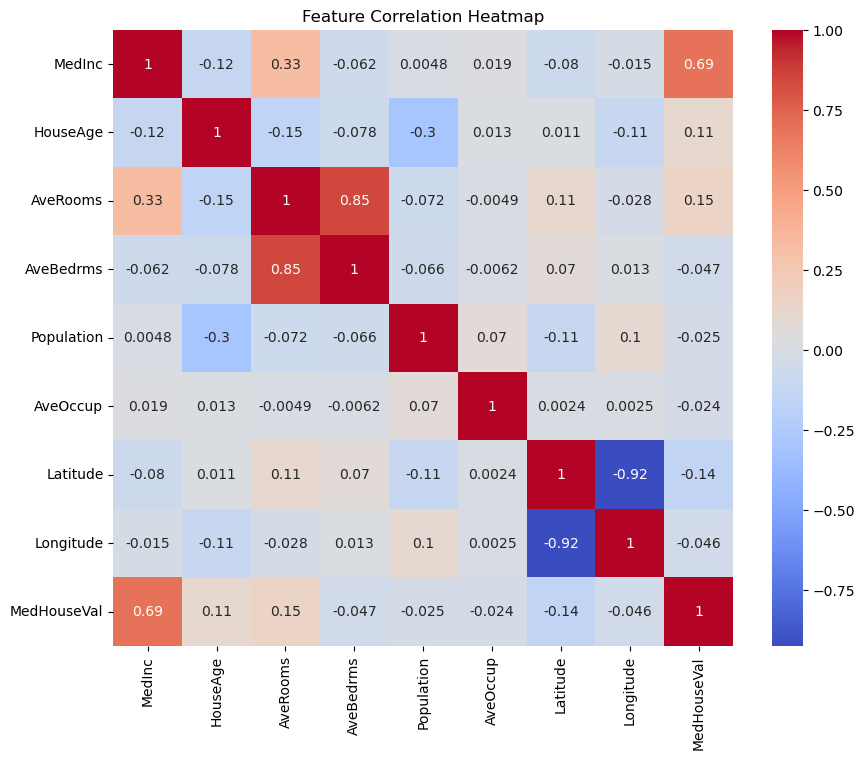

In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

**Features and target**

In [9]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


**Scale features**

In [10]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Train-Test Split**

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [12]:
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

Training samples: 16512, Test samples: 4128


**Create and train Gradient Boosting Regressor**

In [13]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

**Predictions**

In [14]:
y_pred = gbr.predict(X_test)

**Model Evaluation**

In [15]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [16]:
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

Mean Squared Error (MSE): 0.2940
Root Mean Squared Error (RMSE): 0.5422
Mean Absolute Error (MAE): 0.3716
R² Score: 0.7756


**Hyperparameter Tuning with GridSearchCV**

In [17]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5]
}

In [18]:
grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    scoring='r2',
    verbose=2
)

In [19]:
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
best_gbr = grid_search.best_estimator_

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200, 'subsample': 0.8}


In [20]:
# Evaluate best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print(f"R^2 Score after tuning: {r2_score(y_test, y_pred_best):.4f}")

R^2 Score after tuning: 0.8308


**Evaluate Tuned Model**

In [21]:
y_pred_tuned = best_gbr.predict(X_test)

In [22]:
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

In [23]:
print(f"After Tuning - RMSE: {rmse_tuned:.4f}, R² Score: {r2_tuned:.4f}")

After Tuning - RMSE: 0.4709, R² Score: 0.8308


**Feature Importance Visualization**

In [24]:
# Feature importance
feature_importance = best_gbr.feature_importances_
features = X.columns

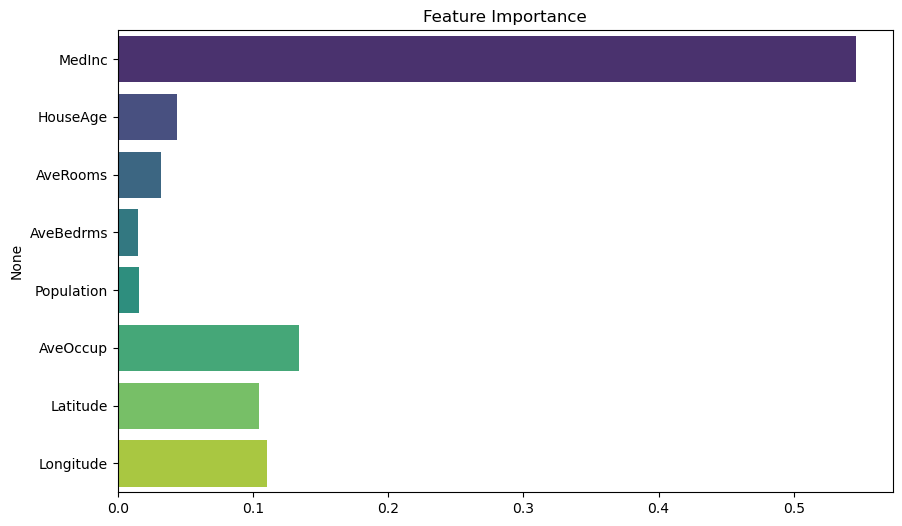

In [25]:
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance, y=features, palette="viridis")
plt.title("Feature Importance")
plt.show()

**Learning Curve**

In [26]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    GradientBoostingRegressor(**grid_search.best_params_, random_state=42),
    X_scaled, y, cv=3, scoring='r2', n_jobs=-1
)

In [27]:
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

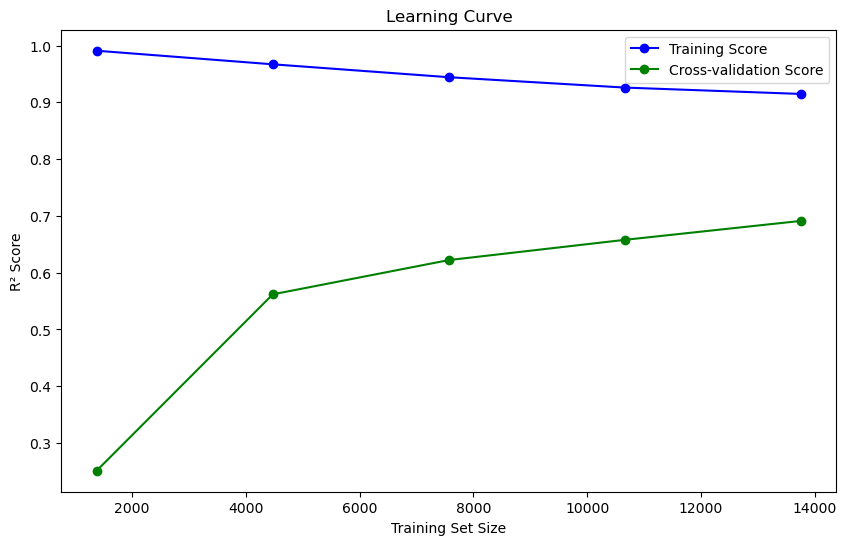

In [28]:
plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='green', label='Cross-validation Score')
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.title("Learning Curve")
plt.legend()
plt.show()

**Partial Dependence Plots**

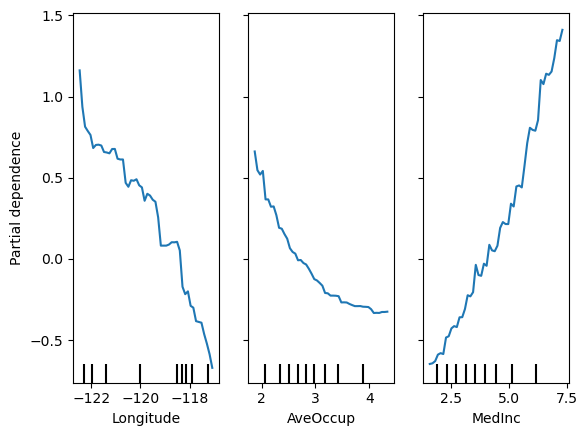

In [29]:
from sklearn.inspection import PartialDependenceDisplay

# Top 3 most important features
top_features = X.columns[np.argsort(feature_importance)[-3:]]

# Plot Partial Dependence
PartialDependenceDisplay.from_estimator(
    best_gbr,      # Your trained GradientBoostingRegressor
    X_train,       # Training data
    features=top_features,  # List of top features
    grid_resolution=50,     # Number of points to evaluate
    kind='average'          # 'average' for average effect
)
plt.show()

### Gradient Boosting Regressor: Detailed Explanation

**What is it?**  
Gradient Boosting Regressor (GBR) is an **ensemble learning technique** that builds a strong predictive model by combining multiple weak learners (usually decision trees) in a stage-wise fashion. Each new tree corrects the errors of the previous one.

**When to use it?**  
- Regression problems with non-linear relationships  
- High predictive accuracy is required  
- When overfitting can be managed with hyperparameter tuning  

**Advantages:**  
- High accuracy and flexibility  
- Can handle mixed types of features  
- Reduces bias effectively  

**Disadvantages:**  
- Slower to train on large datasets  
- Sensitive to noisy data and outliers  
- Requires careful hyperparameter tuning  

**Key Hyperparameters:**  
- `n_estimators`: Number of boosting stages (trees). More trees = better fit but higher risk of overfitting  
- `learning_rate`: Shrinks contribution of each tree. Lower = better generalization but more trees needed  
- `max_depth`: Maximum depth of each tree. Controls complexity  
- `subsample`: Fraction of samples for fitting each tree (stochastic boosting)  
- `min_samples_split`, `min_samples_leaf`: Control tree growth  

**Practical Tips:**  
- Start with default parameters, tune `n_estimators`, `learning_rate`, and `max_depth`  
- Use early stopping with `validation_set` to prevent overfitting  
- Scale features if ranges vary significantly  

